# 03 — Train Super-Resolution CNN

Trains a small ESPCN-style CNN to upscale 32×32 LR tiles to 128×128 HR.
Evaluates against bicubic baseline using PSNR and SSIM.

**Re-runnable:** reads from `data/manifest.csv` — add more data, regenerate the manifest, re-run this notebook.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../src').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

from model import SuperResCNN, PerceptualLoss
from dataset import SRDataset
from degrade import bicubic_upscale

%matplotlib inline

MANIFEST = '../data/manifest.csv'
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Use Apple GPU if available, otherwise CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

Device: mps


## Step 1: Load datasets

In [2]:
train_ds = SRDataset(MANIFEST, split='train', augment=True)
val_ds   = SRDataset(MANIFEST, split='val',   augment=False)
test_ds  = SRDataset(MANIFEST, split='test',  augment=False)

BATCH_SIZE = 16

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

# Sanity check: grab one batch
lr_batch, hr_batch = next(iter(train_loader))
print(f'LR batch: {lr_batch.shape}  HR batch: {hr_batch.shape}')

Train: 368  Val: 76  Test: 83
LR batch: torch.Size([16, 3, 32, 32])  HR batch: torch.Size([16, 3, 128, 128])


## Step 2: Create model

In [3]:
model = SuperResCNN(scale=4, n_resblocks=4, n_feats=64).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

l1_loss = nn.L1Loss()
perceptual_loss = PerceptualLoss().to(DEVICE)
PERCEPTUAL_WEIGHT = 0.01

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f'Loss: L1 + {PERCEPTUAL_WEIGHT} * perceptual (VGG16)')

Parameters: 324,912
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/grahambillington/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [01:02<00:00, 8.91MB/s] 


Loss: L1 + 0.01 * perceptual (VGG16)


## Step 3: Train

In [4]:
EPOCHS = 200
PATIENCE = 15

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_state = model.state_dict()
wait = 0

for epoch in range(1, EPOCHS + 1):
    # -- Train --
    model.train()
    epoch_loss = 0.0
    for lr, hr in train_loader:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        pred = model(lr)
        loss = l1_loss(pred, hr) + PERCEPTUAL_WEIGHT * perceptual_loss(pred, hr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * lr.size(0)
    train_losses.append(epoch_loss / len(train_ds))

    # -- Validate --
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for lr, hr in val_loader:
            lr, hr = lr.to(DEVICE), hr.to(DEVICE)
            pred = model(lr)
            val_loss += l1_loss(pred, hr).item() * lr.size(0)
    val_losses.append(val_loss / len(val_ds))

    # LR scheduler
    scheduler.step(val_losses[-1])

    # Early stopping
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{EPOCHS}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}  lr={lr_now:.1e}')

    if wait >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
        break

# Restore best model
model.load_state_dict(best_state)
model.to(DEVICE)
print(f'\nBest val loss: {best_val_loss:.4f} — model restored to best checkpoint')

Epoch   1/200  train=0.1301  val=0.0914  lr=1.0e-03
Epoch  10/200  train=0.0703  val=0.0661  lr=1.0e-03
Epoch  20/200  train=0.0692  val=0.0649  lr=1.0e-03
Epoch  30/200  train=0.0678  val=0.0639  lr=1.0e-03
Epoch  40/200  train=0.0666  val=0.0625  lr=1.0e-03
Epoch  50/200  train=0.0602  val=0.0566  lr=1.0e-03
Epoch  60/200  train=0.0596  val=0.0561  lr=1.0e-03
Epoch  70/200  train=0.0592  val=0.0559  lr=1.0e-03
Epoch  80/200  train=0.0586  val=0.0555  lr=1.0e-03
Epoch  90/200  train=0.0586  val=0.0558  lr=1.0e-03
Epoch 100/200  train=0.0583  val=0.0548  lr=5.0e-04
Epoch 110/200  train=0.0574  val=0.0547  lr=5.0e-04
Epoch 120/200  train=0.0573  val=0.0546  lr=5.0e-04
Epoch 130/200  train=0.0570  val=0.0543  lr=2.5e-04
Epoch 140/200  train=0.0568  val=0.0544  lr=1.3e-04
Epoch 150/200  train=0.0566  val=0.0542  lr=6.3e-05
Epoch 160/200  train=0.0567  val=0.0542  lr=3.1e-05
Epoch 170/200  train=0.0566  val=0.0542  lr=7.8e-06

Early stopping at epoch 171 (no improvement for 15 epochs)

Bes

## Step 4: Loss curves

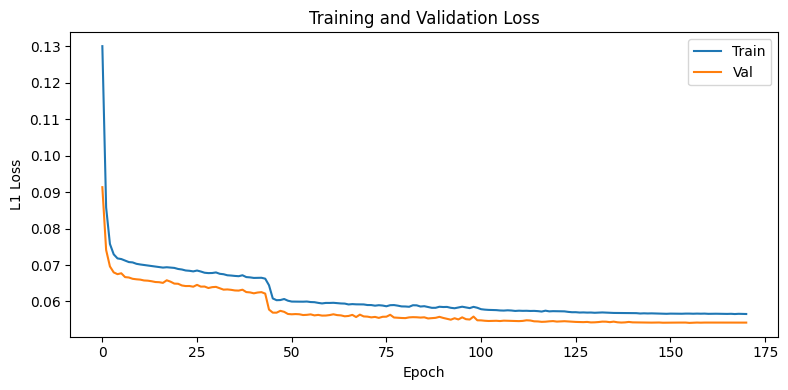

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('L1 Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'loss_curves.png', bbox_inches='tight')
plt.show()

## Step 5: Evaluate on test set

Compare CNN output vs bicubic baseline, both measured against HR ground truth using PSNR and SSIM.

In [6]:
model.eval()

cnn_psnr, cnn_ssim = [], []
bic_psnr, bic_ssim = [], []

with torch.no_grad():
    for lr, hr in test_loader:
        pred = model(lr.to(DEVICE)).cpu()
        for i in range(lr.size(0)):
            # Convert to uint8 numpy HWC for metrics
            hr_np   = (hr[i].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
            pred_np = (pred[i].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
            lr_np   = (lr[i].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
            bic_np  = bicubic_upscale(lr_np, scale=4)

            cnn_psnr.append(psnr(hr_np, pred_np, data_range=255))
            cnn_ssim.append(ssim(hr_np, pred_np, data_range=255, channel_axis=2))
            bic_psnr.append(psnr(hr_np, bic_np, data_range=255))
            bic_ssim.append(ssim(hr_np, bic_np, data_range=255, channel_axis=2))

print(f'{"Method":<12} {"PSNR (dB)":>10} {"SSIM":>10}')
print(f'{"Bicubic":<12} {np.mean(bic_psnr):>10.2f} {np.mean(bic_ssim):>10.4f}')
print(f'{"CNN":<12} {np.mean(cnn_psnr):>10.2f} {np.mean(cnn_ssim):>10.4f}')
print(f'{"":<12} {"":>10} {"":>10}')
delta_psnr = np.mean(cnn_psnr) - np.mean(bic_psnr)
delta_ssim = np.mean(cnn_ssim) - np.mean(bic_ssim)
print(f'{"CNN - Bic":<12} {delta_psnr:>+10.2f} {delta_ssim:>+10.4f}')

Method        PSNR (dB)       SSIM
Bicubic           23.65     0.5244
CNN               24.51     0.6169
                                  
CNN - Bic         +0.86    +0.0925


## Step 6: Visual comparison

Side-by-side: LR | Bicubic | CNN | HR ground truth

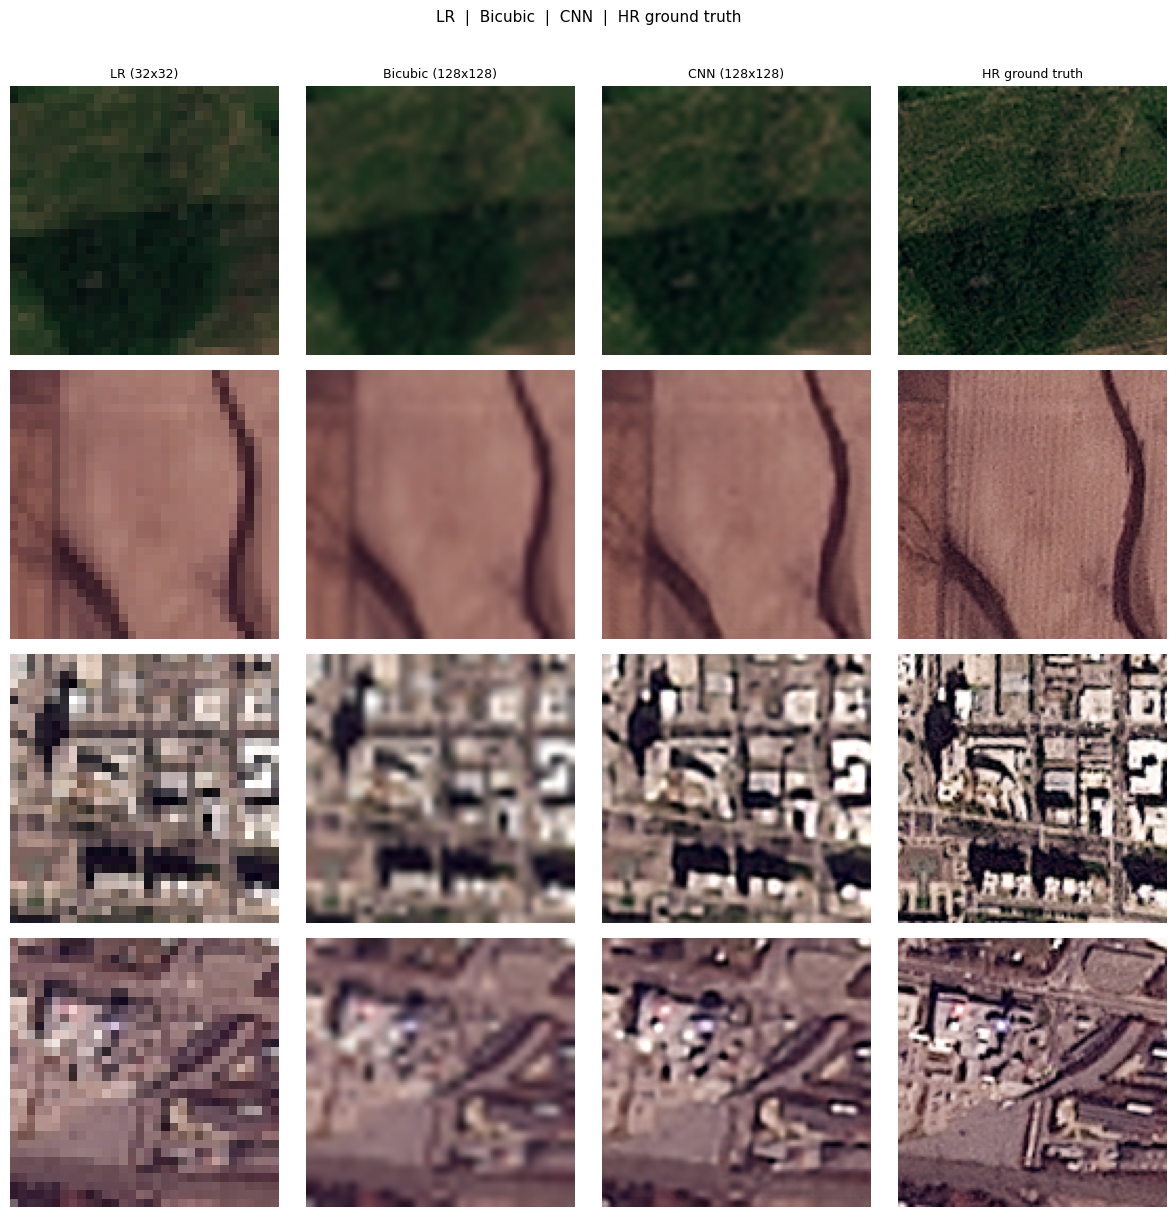

In [7]:
# Show one sample per AOI from the test set
import pandas as pd

model.eval()
manifest = pd.read_csv(MANIFEST)
test_manifest = manifest[manifest['split'] == 'test']
aois = sorted(test_manifest['aoi'].unique())

fig, axes = plt.subplots(len(aois), 4, figsize=(12, 3 * len(aois)))
col_titles = ['LR (32x32)', 'Bicubic (128x128)', 'CNN (128x128)', 'HR ground truth']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=9)

for row, aoi in enumerate(aois):
    sample = test_manifest[test_manifest['aoi'] == aoi].iloc[0]
    lr_np = np.array(Image.open(sample['lr_path']))
    hr_np = np.array(Image.open(sample['hr_path']))
    bic_np = bicubic_upscale(lr_np, scale=4)

    lr_t = torch.from_numpy(lr_np).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    with torch.no_grad():
        pred_t = model(lr_t.to(DEVICE)).cpu()
    pred_np = (pred_t[0].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)

    for ax, img in zip(axes[row], [lr_np, bic_np, pred_np, hr_np]):
        ax.imshow(img)
        ax.axis('off')
    axes[row, 0].set_ylabel(aoi, fontsize=8, rotation=90, labelpad=40)

plt.suptitle('LR  |  Bicubic  |  CNN  |  HR ground truth', fontsize=11, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cnn_vs_bicubic.png', bbox_inches='tight')
plt.show()

## Step 7: Save model

In [8]:
save_path = Path('../models/superres_v1.pth')
save_path.parent.mkdir(exist_ok=True)
torch.save(model.state_dict(), save_path)
print(f'Model saved to {save_path}')

Model saved to ../models/superres_v1.pth
